In [1]:
!which python
!python --version

/home/commander-data/Storage/users/mave/.venv/bin/python
Python 3.12.9


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.mixture import GaussianMixture

In [3]:
basepath = "/home/commander-data/Storage/users/mave/search_sequences_300_var"
datapath = '/'.join([basepath, "data/input/test/X205SC23111498-Z01-F020/01.RawData"])
sspath = '/'.join([basepath, "data/input/search_sequences"])
plotpath = '/'.join([basepath, "data/output/plots"])

In [4]:
# read search sequences
search_sequences = []

for filepath in Path(sspath).iterdir():
    if filepath.is_file():
        new_data = pd.read_csv(filepath, sep = " ", header = None)
        new_data["modality"] = filepath.name.split('_')[2].split('.')[0]
        search_sequences.append(new_data)

search_sequences = pd.concat(search_sequences)
search_sequences.columns = ["combined_var_id", "seq", "modality"]
search_sequences

,combined_var_id,seq,modality
0,chr17-31233004-T-C_chr17-31233015-C-T,CTCCATAGGCCTAGGTTACCATAAGGATCTCC,RNA
1,chr17-31233005-T-G_chr17-31233012-C-T,TCCATAGGCTGAGGTTATCACAAGGATC,RNA
2,chr17-31233016-A-T_chr17-31233021-T-C,AGGTTACCACTAGGACCTCCAGACAA,RNA
3,chr17-31233018-G-A_chr17-31233024-C-A,GTTACCACAAAGATCTACAGACAAGAG,RNA
4,chr17-31233072-A-G_chr17-31233075-C-A,TCCTTCAACAGGGAACAGAATTTG,RNA
...,...,...,...
59,chr17-31336865-C-T_chr17-31336856-T-C,CTTCCACACACGGACTGGTTATTAATATCA,DNA
60,chr17-31336865-C-T_chr17-31336868-T-A,ATGGACTGGTTATAAATATCATTC,DNA
61,chr17-31336867-T-G_chr17-31336860-C-T,CACACATGGATTGGTCAGTAATATCATT,DNA
62,chr17-31336867-T-G_chr17-31336865-C-G,ATGGACTGGTGAGTAATATCATT,DNA


In [5]:
# read in counts
result = []

for subdir in Path(datapath).iterdir():
    if subdir.is_dir():
        matches = list(subdir.glob("*_results_total.tsv"))
        if matches:
            for filepath in matches:
                new_data = pd.read_csv(filepath, sep = "\t", comment = "#")
                new_data["file"] = filepath.name
                result.append(new_data)
        else:
            print("NOTHING FOUND")
result = pd.concat(result)

result["modality"] = [x.split('_')[0] for x in result["file"]]
result["exon"] = [x.split('_')[1] for x in result["file"]]
result["cell_line"] = [x.split('_')[2] for x in result["file"]]
result["replicate"] = [x.split('_')[3] for x in result["file"]]
result = result.drop_duplicates()

result["counts_complete"] = result["counts_complete"] + 1
result["total_reads"] = result["total_reads"] + 1
result["fraction"] = result["counts_complete"] / result["total_reads"]
result["RPM"] = result["fraction"] * 1000000

result = result.merge(search_sequences, on = ["seq", "modality"], how = "left")
result

,seq,counts_complete,total_reads,fraction,RPM,file,modality,exon,cell_line,replicate,combined_var_id
0,ATTCCCTTGAGGTAGCAGCTCATC,5355,10634189.0,5.035645e-04,503.564494,RNA_E42_KBM7_R2_results_total.tsv,RNA,E42,KBM7,R2,chr17-31336772-T-G_chr17-31336775-G-A
1,GCCACAGGTCGGCTATCCCTTAGAG,5275,10634189.0,4.960416e-04,496.041588,RNA_E42_KBM7_R2_results_total.tsv,RNA,E42,KBM7,R2,chr17-31336831-C-G_chr17-31336835-C-A
2,TAGCCACAGGGCCGGTCTCCCTTAG,5036,10634189.0,4.735669e-04,473.566908,RNA_E42_KBM7_R2_results_total.tsv,RNA,E42,KBM7,R2,chr17-31336833-C-G_chr17-31336829-T-G
3,TAGTAGCCACTGGTACGCTCTCCCT,3321,10634189.0,3.122946e-04,312.294619,RNA_E42_KBM7_R2_results_total.tsv,RNA,E42,KBM7,R2,chr17-31336830-C-A_chr17-31336826-A-T
4,CCCTTGATGTCGTAGCTCATCTT,3188,10634189.0,2.997878e-04,299.787788,RNA_E42_KBM7_R2_results_total.tsv,RNA,E42,KBM7,R2,chr17-31336777-C-T_chr17-31336775-G-C
...,...,...,...,...,...,...,...,...,...,...,...
4586,GAGCCTCTCTTCGGTAGGGAAAAGG,1,16723643.0,5.979558e-08,0.059796,RNA_E17_K562_R3_results_total.tsv,RNA,E17,K562,R3,chr17-31225227-A-T_chr17-31225223-C-T
4587,TCCTTTTTTAGGGGGTAGGCTGTGATATTC,1,16723643.0,5.979558e-08,0.059796,RNA_E17_K562_R3_results_total.tsv,RNA,E17,K562,R3,chr17-31225133-C-G_chr17-31225142-A-C
4588,TGAAGAATTAGTACGGACTCCTGGAG,1,16723643.0,5.979558e-08,0.059796,RNA_E17_K562_R3_results_total.tsv,RNA,E17,K562,R3,chr17-31225200-C-G_chr17-31225205-T-G
4589,TGAAGAATTAGTACGTACTCCAGGAGCCTCTC,1,16723643.0,5.979558e-08,0.059796,RNA_E17_K562_R3_results_total.tsv,RNA,E17,K562,R3,chr17-31225200-C-G_chr17-31225211-T-A


In [6]:
# pivot such that each combined variant has the rpm dna and rpm rna in one line
wide = (
    result.pivot_table(
        index=["combined_var_id", "exon", "cell_line", "replicate"],
        columns="modality",
        values="RPM"
    ).reset_index().rename_axis(None, axis=1).rename(columns={"DNA": "RPM_DNA", "RNA": "RPM_RNA"})
)
wide["ratio"] = wide["RPM_RNA"] / wide["RPM_DNA"]
wide

,combined_var_id,exon,cell_line,replicate,RPM_DNA,RPM_RNA,ratio
0,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R1,0.294707,0.546905,1.855760
1,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R2,0.190478,0.499198,2.620767
2,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R3,0.333474,0.538160,1.613799
3,chr17-31225098-G-A_chr17-31225106-A-G,E17,KBM7,R1,0.328189,0.125268,0.381696
4,chr17-31225098-G-A_chr17-31225106-A-G,E17,KBM7,R2,0.419759,0.293786,0.699892
...,...,...,...,...,...,...,...
2041,chr17-31336867-T-G_chr17-31336871-T-C,E42,K562,R2,0.059695,0.103503,1.733878
2042,chr17-31336867-T-G_chr17-31336871-T-C,E42,K562,R3,0.195176,0.219543,1.124847
2043,chr17-31336867-T-G_chr17-31336871-T-C,E42,KBM7,R1,0.061443,0.092669,1.508218
2044,chr17-31336867-T-G_chr17-31336871-T-C,E42,KBM7,R2,0.121473,0.176136,1.450005


In [ ]:
# annotate library information
library = pd.read_csv(basepath + "/data/input/Overview_edit_names.tsv", sep = "\t")

wide_annotated = wide.merge(library, on = "combined_var_id")
wide_annotated["clinvar_simple"] = wide_annotated["clinvar"].map({
    "unknown": "unknown",
    "Uncertain_significance": "VUS",
    "Likely_benign": "benign",
    "Conflicting_classifications_of_pathogenicity": "conflicting",
    "Pathogenic": "pathogenic",
    "Likely_pathogenic": "pathogenic",
    "Pathogenic/Likely_pathogenic": "pathogenic",
    "Benign/Likely_benign": "benign"
})
wide_annotated["cprime_score"] = wide_annotated["RPM_RNA"] / wide_annotated["RPM_DNA"]
wide_annotated

,combined_var_id,exon,cell_line,replicate,RPM_DNA,RPM_RNA,ratio,var_id,syn_var,start_combined,...,pegRNA_extension_sequence_order_TOP,pegRNA_extension_sequence_order_BOTTOM,RHA_length,longest_T_stretch_spacer,longest_T_stretch_extension,longest_T_stretch,complete_peg_rna,gene,clinvar_simple,cprime_score
0,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R1,0.294707,0.546905,1.855760,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,...,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting,1.855760
1,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R2,0.190478,0.499198,2.620767,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,...,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting,2.620767
2,chr17-31225098-G-A_chr17-31225106-A-G,E17,K562,R3,0.333474,0.538160,1.613799,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,...,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting,1.613799
3,chr17-31225098-G-A_chr17-31225106-A-G,E17,KBM7,R1,0.328189,0.125268,0.381696,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,...,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting,0.381696
4,chr17-31225098-G-A_chr17-31225106-A-G,E17,KBM7,R2,0.419759,0.293786,0.699892,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,...,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting,0.699892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2041,chr17-31336867-T-G_chr17-31336871-T-C,E42,K562,R2,0.059695,0.103503,1.733878,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,...,gtgcTgTTAcTGACCAGTCCATGTGTGGAAG,aaaaCTTCCACACATGGACTGGTCAgTAAcA,21.0,2.0,2.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown,1.733878
2042,chr17-31336867-T-G_chr17-31336871-T-C,E42,K562,R3,0.195176,0.219543,1.124847,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,...,gtgcTgTTAcTGACCAGTCCATGTGTGGAAG,aaaaCTTCCACACATGGACTGGTCAgTAAcA,21.0,2.0,2.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown,1.124847
2043,chr17-31336867-T-G_chr17-31336871-T-C,E42,KBM7,R1,0.061443,0.092669,1.508218,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,...,gtgcTgTTAcTGACCAGTCCATGTGTGGAAG,aaaaCTTCCACACATGGACTGGTCAgTAAcA,21.0,2.0,2.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown,1.508218
2044,chr17-31336867-T-G_chr17-31336871-T-C,E42,KBM7,R2,0.121473,0.176136,1.450005,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,...,gtgcTgTTAcTGACCAGTCCATGTGTGGAAG,aaaaCTTCCACACATGGACTGGTCAgTAAcA,21.0,2.0,2.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown,1.450005


In [9]:
# take mean of replicates
wide_mean = wide_annotated[["combined_var_id", "cell_line", "RPM_DNA", "RPM_RNA"]].groupby(["combined_var_id", "cell_line"]).mean().reset_index()
wide_mean["cprime_score"] = wide_mean["RPM_RNA"] / wide_mean["RPM_DNA"]
wide_mean = wide_mean.merge(library, on = "combined_var_id", how = "left")
# fill missing clinvar
missing_values = pd.DataFrame([
    {"combined_var_id": "chr17-31233005-T-G_old", "clinvar": "Pathogenic"},
    {"combined_var_id": "chr17-31233016-A-T_old", "clinvar": "unknown"},
    {"combined_var_id": "chr17-31233072-A-G_old", "clinvar": "Conflicting_classifications_of_pathogenicity"},
    {"combined_var_id": "chr17-31233123-G-A_old", "clinvar": "Likely_benign"},
    {"combined_var_id": "chr17-31233126-A-G_old", "clinvar": "Conflicting_classifications_of_pathogenicity"},
    {"combined_var_id": "chr17-31233128-T-A_old", "clinvar": "Pathogenic"},
    {"combined_var_id": "chr17-31233133-G-T_old", "clinvar": "Pathogenic"},
    {"combined_var_id": "chr17-31233156-T-G_old", "clinvar": "Likely_pathogenic"},
    {"combined_var_id": "chr17-31233157-C-T_old", "clinvar": "Pathogenic"},
])
clinvar_map = missing_values.set_index('combined_var_id')['clinvar']
wide_mean['clinvar'] = wide_mean['clinvar'].fillna(
    wide_mean['combined_var_id'].map(clinvar_map)
)
wide_mean["clinvar_simple"] = wide_mean["clinvar"].map({
    "unknown": "unknown",
    "Uncertain_significance": "VUS",
    "Likely_benign": "benign",
    "Conflicting_classifications_of_pathogenicity": "conflicting",
    "Pathogenic": "pathogenic",
    "Likely_pathogenic": "pathogenic",
    "Pathogenic/Likely_pathogenic": "pathogenic",
    "Benign/Likely_benign": "benign"
})
wide_mean

,combined_var_id,cell_line,RPM_DNA,RPM_RNA,cprime_score,var_id,syn_var,start_combined,pangolin_gain_score_combined,pangolin_gain_pos_combined,...,Spacer_sequence_order_BOTTOM,pegRNA_extension_sequence_order_TOP,pegRNA_extension_sequence_order_BOTTOM,RHA_length,longest_T_stretch_spacer,longest_T_stretch_extension,longest_T_stretch,complete_peg_rna,gene,clinvar_simple
0,chr17-31225098-G-A_chr17-31225106-A-G,K562,0.272886,0.528088,1.935194,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,0.10,43.0,...,ctctaaaacGTCACTTTCTCCTTTTTTAC,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting
1,chr17-31225098-G-A_chr17-31225106-A-G,KBM7,0.320949,0.275505,0.858406,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,0.10,43.0,...,ctctaaaacGTCACTTTCTCCTTTTTTAC,gtgcGaCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGtC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting
2,chr17-31225098-G-A_chr17-31225109-T-C,K562,0.384005,0.872759,2.272781,chr17-31225098-G-A,chr17-31225109-T-C,31225098.0,0.07,43.0,...,ctctaaaacGTCACTTTCTCCTTTTTTAC,gtgcGaCAGATAGAAGcTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAgCTTCTATCTGtC,19.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting
3,chr17-31225098-G-A_chr17-31225109-T-C,KBM7,0.390721,0.538887,1.379213,chr17-31225098-G-A,chr17-31225109-T-C,31225098.0,0.07,43.0,...,ctctaaaacGTCACTTTCTCCTTTTTTAC,gtgcGaCAGATAGAAGcTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAgCTTCTATCTGtC,19.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,conflicting
4,chr17-31225098-G-T_chr17-31225106-A-G,K562,0.063999,0.220722,3.448860,chr17-31225098-G-T,chr17-31225106-A-G,31225098.0,0.18,43.0,...,ctctaaaacGTCACTTTCTCCTTTTTTAC,gtgcGtCAGATAGgAGTTCCTGTCACTTTCTCCTTT,aaaaAAAGGAGAAAGTGACAGGAACTcCTATCTGaC,22.0,1.0,3.0,3.0,GTAAAAAAGGAGAAAGTGACgttttagagctagaaatagcaagtta...,NF1,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,chr17-31336867-T-G_chr17-31336860-C-T,KBM7,0.196499,0.520387,2.648287,chr17-31336867-T-G,chr17-31336860-C-T,31336860.0,0.33,2.0,...,ctctaaaacGTCCATGTGTGGAAGCTCTAC,gtgcTAcTGACCAaTCCATGTGTGGAA,aaaaTTCCACACATGGAtTGGTCAgTA,13.0,2.0,1.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown
678,chr17-31336867-T-G_chr17-31336865-C-G,K562,0.055605,0.106962,1.923613,chr17-31336867-T-G,chr17-31336865-C-G,31336865.0,0.86,-3.0,...,ctctaaaacGTCCATGTGTGGAAGCTCTAC,gtgcTAcTcACCAGTCCATGTGTGGAA,aaaaTTCCACACATGGACTGGTgAgTA,18.0,2.0,1.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown
679,chr17-31336867-T-G_chr17-31336865-C-G,KBM7,0.060087,0.082901,1.379678,chr17-31336867-T-G,chr17-31336865-C-G,31336865.0,0.86,-3.0,...,ctctaaaacGTCCATGTGTGGAAGCTCTAC,gtgcTAcTcACCAGTCCATGTGTGGAA,aaaaTTCCACACATGGACTGGTgAgTA,18.0,2.0,1.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown
680,chr17-31336867-T-G_chr17-31336871-T-C,K562,0.123840,0.143552,1.159172,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,0.36,-5.0,...,ctctaaaacGTCCATGTGTGGAAGCTCTAC,gtgcTgTTAcTGACCAGTCCATGTGTGGAAG,aaaaCTTCCACACATGGACTGGTCAgTAAcA,21.0,2.0,2.0,2.0,TAGAGCTTCCACACATGGACgttttagagctagaaatagcaagtta...,NF1,unknown


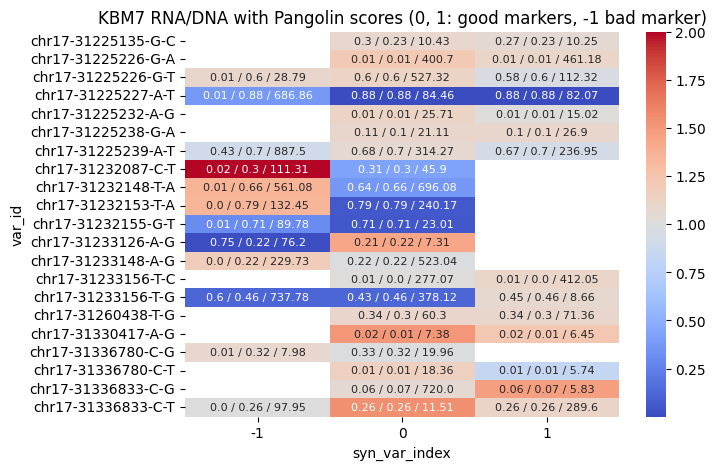

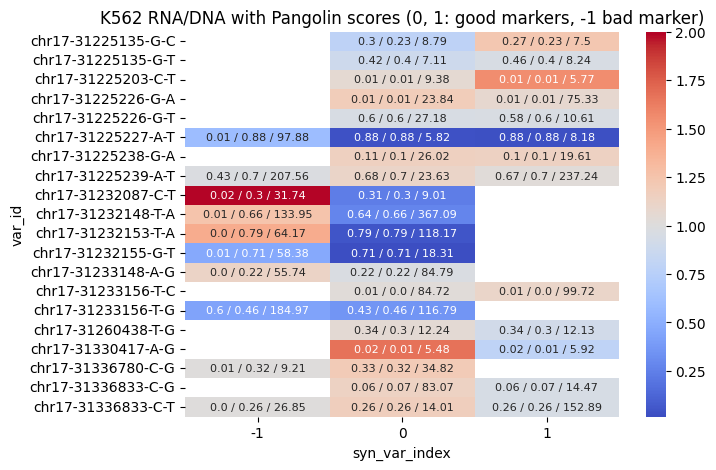

In [ ]:
# compute heatmap of bad and good marker variants
for cell_line_oi in ["KBM7", "K562"]:
    plotdat = wide_mean.copy()
    plotdat = plotdat[plotdat["cell_line"] == cell_line_oi]
    plotdat = plotdat[plotdat["RPM_DNA"] >= 5]
    plotdat = plotdat[plotdat["source"].isin(["ss_lib", "bad_marker_lib"])]
    plotdat["cprime_score"] = plotdat["cprime_score"].clip(upper=2)#np.log2(plotdat["cprime_score"])
    plotdat["var_id"] = [x.split('_')[0] for x in plotdat["combined_var_id"]]
    plotdat["syn_var_id"] = [x.split('_')[1] for x in plotdat["combined_var_id"]]
    new_plotdat = []
    for group in plotdat.groupby("var_id"):
        group = group[1]
        new_data = []
        good_markers = group[group["source"] != "bad_marker_lib"].copy()
        if good_markers.shape[0] > 0:
            good_markers["syn_var_index"] = range(good_markers.shape[0])
            new_data.append(good_markers)
        bad_markers = group[group["source"] == "bad_marker_lib"].copy()
        if bad_markers.shape[0] > 0:
            bad_markers["syn_var_index"] =  [(x + 1) * -1 for x in range(bad_markers.shape[0])]
            new_data.append(bad_markers)
        new_plotdat.append(pd.concat(new_data))
    new_plotdat = pd.concat(new_plotdat)
    new_plotdat["syn_var_index"] = new_plotdat["syn_var_index"].astype(str)


    # plot the figure
    heatmap_df = new_plotdat.drop_duplicates().pivot(index="var_id", columns="syn_var_index", values="cprime_score")
    heatmap_df = heatmap_df[(~heatmap_df.isna()).sum(axis = 1) > 1] # remove rows with only one marker left

    new_plotdat["pangolin_annot"] = new_plotdat["pangolin_gain_score_combined"].astype(str)+ " / " + new_plotdat["pangolin_gain"].astype(str) + " / " + new_plotdat["RPM_DNA"].round(2).astype(str)
    pangolin_df = new_plotdat.pivot(index = "var_id", columns = "syn_var_index", values = "pangolin_annot")
    pangolin_df = pangolin_df.reindex_like(heatmap_df)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        heatmap_df,
        cmap = "coolwarm",
        center = 1,
        annot = pangolin_df.round(2),
        fmt = "",
        annot_kws = {"size": 8}
    )
    plt.title(cell_line_oi + " RNA/DNA with Pangolin scores (0, 1: good markers, -1 bad marker)")
    #plt.tight_layout()
    
    plt.savefig(
        '/'.join([plotpath, cell_line_oi + "_good_vs_bad_markers.pdf"]),
        format = "pdf",
        bbox_inches = "tight"
    )

    plt.show()


(29, 4)
clinvar_simple
benign        19
pathogenic    10
Name: count, dtype: int64


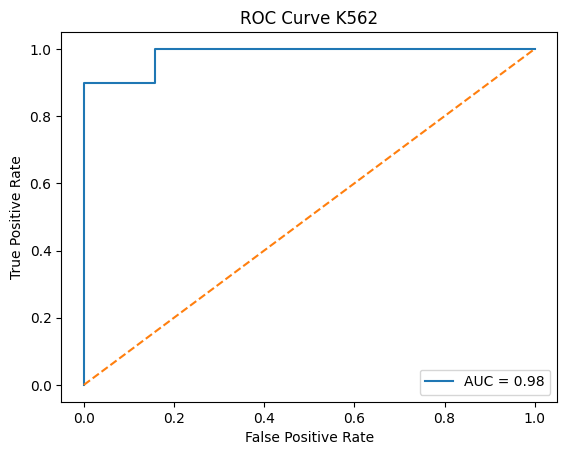

LOO AUC range: 0.9824561403508771 1.0
AUC: 0.9842105263157894
95% CI: 0.9242132867132866 - 1.0
p-value: 0.0
(30, 4)
clinvar_simple
benign        19
pathogenic    11
Name: count, dtype: int64


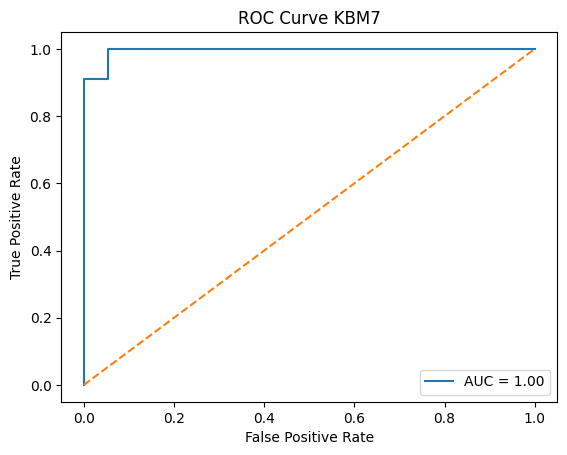

LOO AUC range: 0.9947368421052631 1.0
AUC: 0.9952153110047846
95% CI: 0.9728506787330317 - 1.0
p-value: 0.0


In [ ]:
cell_lines = ["K562", "KBM7"]

for cell_line_oi in cell_lines:
        rocdat = wide_mean.copy()
        rocdat = rocdat[~rocdat["source"].isin(["bad_marker_lib"])] # EXCLUDE BAD MARKER LIB
        rocdat = rocdat[rocdat["clinvar_simple"].isin(["benign", "pathogenic"])] # differentiate between benign and pathogenic variants
        rocdat = rocdat[rocdat["cell_line"].isin([cell_line_oi])]
        rocdat = rocdat[rocdat["RPM_DNA"] >= 5]
        rocdat = rocdat[["var_id", "cprime_score", "clinvar_simple"]].groupby("var_id", as_index=False).agg(cprime_score=("cprime_score", "mean"), clinvar_simple=("clinvar_simple", "first")) # take mean per intended edit
        rocdat["label"] = rocdat["clinvar_simple"] == "pathogenic"

        print(rocdat.shape)
        print(rocdat["clinvar_simple"].value_counts())

        y_true = (rocdat["clinvar_simple"] == "pathogenic").astype(int)
        y_score = -rocdat["cprime_score"] # flip score because lower = more pathogenic

        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)

        # plot
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle="--")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve " + cell_line_oi)
        plt.legend()

        plt.savefig(
            '/'.join([plotpath, cell_line_oi + "_roc.pdf"]),
            format = "pdf",
            bbox_inches="tight"
        )

        plt.show()

        ## do some diagnostics

        # LOO
        aucs = []
        for i in range(len(rocdat)):
            df_loo = rocdat.drop(rocdat.index[i]).copy()
            auc_val = roc_auc_score(df_loo["clinvar_simple"], -df_loo["cprime_score"])
            aucs.append(auc_val)

        print("LOO AUC range:", min(aucs), max(aucs))


        # calculate confidence interval
        y_true = (rocdat["clinvar_simple"] == "pathogenic").astype(int)
        y_score = -rocdat["cprime_score"] # flip direction

        # observed AUC
        observed_auc = roc_auc_score(y_true, y_score)

        # bootstrap
        n_bootstraps = 1000
        bootstrapped_aucs = []
        rng = np.random.default_rng(42)
        for _ in range(n_bootstraps):
            indices = rng.choice(len(rocdat), len(rocdat), replace=True)

            if len(np.unique(y_true.iloc[indices])) < 2:
                continue  # skip invalid samples
            
            auc = roc_auc_score(y_true.iloc[indices], y_score.iloc[indices])
            bootstrapped_aucs.append(auc)

        bootstrapped_aucs = np.array(bootstrapped_aucs)
        ci_lower = np.percentile(bootstrapped_aucs, 2.5)
        ci_upper = np.percentile(bootstrapped_aucs, 97.5)

        print("AUC:", observed_auc)
        print("95% CI:", ci_lower, "-", ci_upper) # CI entirely > 0.5 -> strong evidence that the score works

        # calculate p value
        n_permutations = 1000
        permuted_aucs = []
        for _ in range(n_permutations):
            shuffled = rng.permutation(y_true)
            auc = roc_auc_score(shuffled, y_score)
            permuted_aucs.append(auc)

        permuted_aucs = np.array(permuted_aucs)
        p_value = np.mean(permuted_aucs >= observed_auc)

        print("p-value:", p_value)

source
ss_lib                 53
stop_syn_gained_lib    11
Name: count, dtype: int64


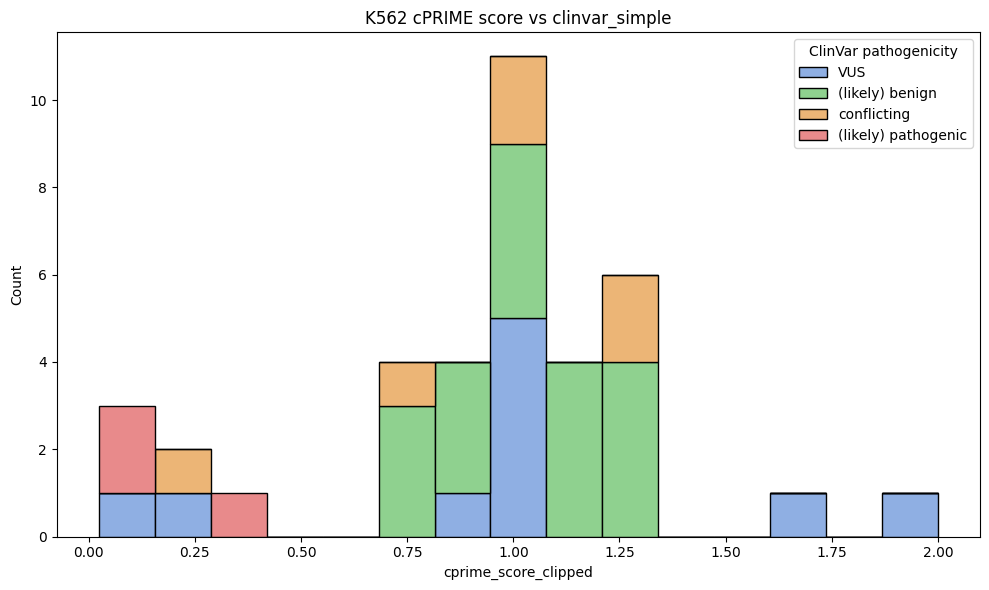

source
ss_lib                 59
stop_syn_gained_lib    11
Name: count, dtype: int64


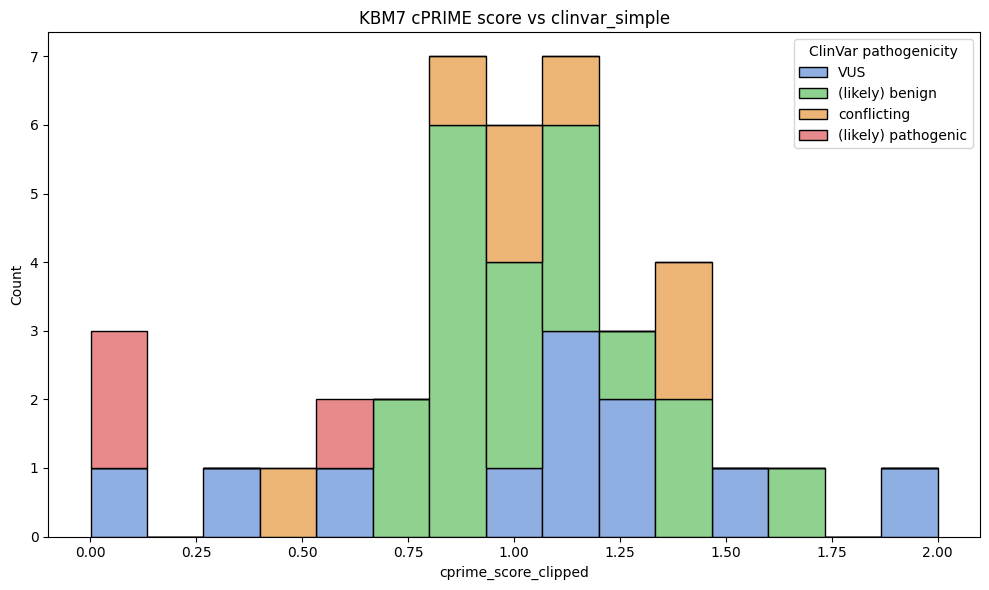

In [ ]:

for column_oi in ["clinvar_simple"]:
    for cell_line in ["K562", "KBM7"]:
        plotdat = wide_mean[wide_mean["cell_line"].isin([cell_line]) & (wide_mean["RPM_DNA"] >= 5) & (wide_mean["source"].isin(["ss_lib", "stop_syn_gained_lib"])) & (wide_mean["consequence"] != "stop_gained")].copy()
        print(plotdat["source"].value_counts())

        plotdat = plotdat[["var_id", "cprime_score", "clinvar_simple"]].groupby("var_id", as_index=False).agg(cprime_score=("cprime_score", "mean"),clinvar_simple=("clinvar_simple", "first")) # take mean per intended edit
        plotdat['cprime_score_clipped'] = plotdat['cprime_score'].clip(lower=0, upper=2) # clip to 0 - 2 -> nicer for visualization

        if column_oi == "clinvar_simple":
            plotdat = plotdat[~plotdat["clinvar_simple"].isin(["unknown"])]
        categories = sorted(plotdat[column_oi].dropna().unique())

        color_map = {
            "pathogenic": "#E88A8B",
            "benign": "#8FD18F",
            "conflicting": "#ECB576",
            "VUS": "#8FAFE3",
        }
        colors = [color_map[c] for c in categories]
        data = [plotdat.loc[plotdat[column_oi] == cat, "cprime_score_clipped"] for cat in categories]

        display_labels = {
            "pathogenic": "(likely) pathogenic",
            "benign": "(likely) benign",
            "conflicting": "conflicting",
            "VUS": "VUS"
        }
        legend_labels = [display_labels[c] for c in categories]

        plt.figure(figsize=(10, 6))
        plt.hist(
            data,
            bins=15,
            stacked=True,
            label=legend_labels,
            color=colors,
            edgecolor="black",
        )
        plt.xlabel("cprime_score_clipped")
        plt.ylabel("Count")
        plt.title(cell_line + " cPRIME score vs " + column_oi)
        plt.legend(title="ClinVar pathogenicity")
        plt.tight_layout()

        plt.savefig(
            '/'.join([plotpath, cell_line + "_cprime_score_vs_pangolin.pdf"]),
            format = "pdf",
            bbox_inches="tight"
        )

        plt.show()

In [27]:
# calculate BIC and AIC to decide how many gaussians fit best
cell_line_oi = "K562"

mm_data = wide_mean[~wide_mean["source"].isin(["bad_marker_lib", "ex27_lib_ss"]) &wide_mean["cell_line"].isin([cell_line_oi]) &(wide_mean["RPM_DNA"] >= 5)].copy()
mm_data = mm_data[["var_id", "cprime_score", "clinvar_simple", "source", "consequence", "pangolin_gain_bin"]].groupby(["var_id", "source"], as_index=False).agg(cprime_score=("cprime_score", "mean"),clinvar_simple=("clinvar_simple", "first"),source=("source", "first"),consequence=("consequence", "first"),pangolin_gain_bin=("pangolin_gain_bin", "first")) # take mean per intended edit

mm_data["cprime_score_norm"] = np.log(mm_data['cprime_score']).clip(lower=-4)
x = mm_data["cprime_score_norm"].to_numpy().reshape(-1, 1)

models = {}
for k in [1, 2, 3, 4, 5]:
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(x)
    models[k] = gmm
    print(f"{k} components: BIC={round(gmm.bic(x), 2)}, AIC={round(gmm.aic(x), 2)}")

1 components: BIC=207.08, AIC=202.7
2 components: BIC=166.2, AIC=155.25
3 components: BIC=159.04, AIC=141.52
4 components: BIC=141.4, AIC=117.32
5 components: BIC=152.65, AIC=122.0


In [23]:
# three components
mm_data = wide_mean[~wide_mean["source"].isin(["bad_marker_lib", "ex27_lib_ss"]) &wide_mean["cell_line"].isin([cell_line_oi]) &(wide_mean["RPM_DNA"] >= 5)].copy()
mm_data = mm_data[["var_id", "cprime_score", "clinvar_simple", "source", "consequence", "pangolin_gain_bin"]].groupby(["var_id", "source"], as_index=False).agg(cprime_score=("cprime_score", "mean"),clinvar_simple=("clinvar_simple", "first"),source=("source", "first"),consequence=("consequence", "first"),pangolin_gain_bin=("pangolin_gain_bin", "first")) # take mean per intended edit

mm_data["cprime_score_norm"] = np.log(mm_data["cprime_score"]).clip(lower=-4)
x = mm_data["cprime_score_norm"].to_numpy().reshape(-1, 1)

gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(x)

probs = gmm.predict_proba(x)
means = gmm.means_.flatten()
order = np.argsort(means)

depleted = order[0]
intermediate = order[1]
neutral = order[2]

df2 = mm_data.copy()
df2["max_prob"] = probs.max(axis=1)
df2["component"] = probs.argmax(axis=1)

label_map = {
    depleted: "responder",
    intermediate: "intermediate",
    neutral: "non_responder",
}

df2["class"] = df2["component"].map(label_map)

print("Means:", means)
print("Weights:", gmm.weights_)
print("BIC:", gmm.bic(x))
print("AIC:", gmm.aic(x))
print(df2["class"].value_counts())

Means: [ 0.04313883 -3.48325941 -1.1515734 ]
Weights: [0.63145378 0.09463961 0.2739066 ]
BIC: 189.6576005873502
AIC: 171.22507984171685
class
non_responder    47
intermediate     20
responder         7
Name: count, dtype: int64


In [24]:
print(pd.crosstab(df2['class'], df2['consequence'], normalize='index'))

consequence    missense_variant  stop_gained  synonymous_variant
class                                                           
intermediate           0.266667     0.600000            0.133333
non_responder          0.382979     0.021277            0.595745
responder              0.428571     0.428571            0.142857


In [25]:
print(pd.crosstab(df2['class'], df2['pangolin_gain_bin'], normalize='index'))

pangolin_gain_bin  high_gain  low_gain  mid_gain  no_splicing
class                                                        
intermediate        0.066667  0.133333  0.200000     0.600000
non_responder       0.000000  0.170213  0.106383     0.723404
responder           0.857143  0.000000  0.142857     0.000000


In [26]:
print(gmm.means_) # one should be negative and one close to 0
print(gmm.weights_)

[[ 0.04313883]
 [-3.48325941]
 [-1.1515734 ]]
[0.63145378 0.09463961 0.2739066 ]


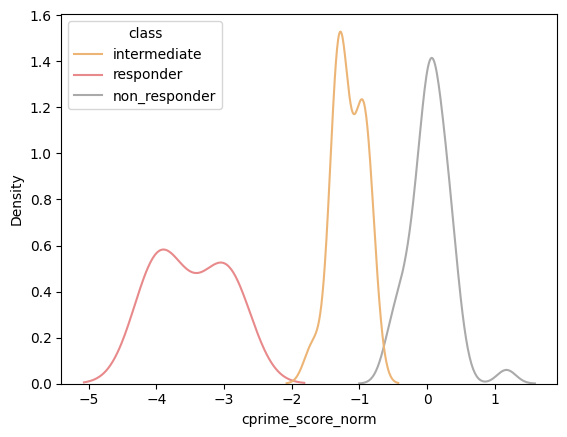

In [29]:
sns.kdeplot(
    data=df2,
    x='cprime_score_norm',
    hue='class',
    common_norm=False,
    palette = {
        "responder": "#E88A8B",
        "intermediate": "#ECB576",
        "non_responder": "#AAAAAA",
    }
)
plt.savefig(
    '/'.join([plotpath, cell_line_oi + "_GMM.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

In [ ]:
# save data to file
df2.to_csv(basepath + "/data/output/" + cell_line_oi + "_GMM_classification.tsv", sep = "\t", index = False)

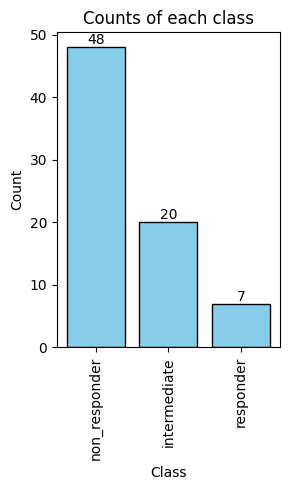

In [ ]:
# Count how many times each class appears
class_counts = df2["class"].value_counts()

plt.figure(figsize=(3, 5))
bars = plt.bar(
    class_counts.index,
    class_counts.values,
    color = "skyblue",
    edgecolor = "black"
)

# Add count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha = "center",
        va="bottom"
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Counts of each class")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    '/'.join([plotpath, cell_line_oi + "_number_of_responders.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

plt.show()

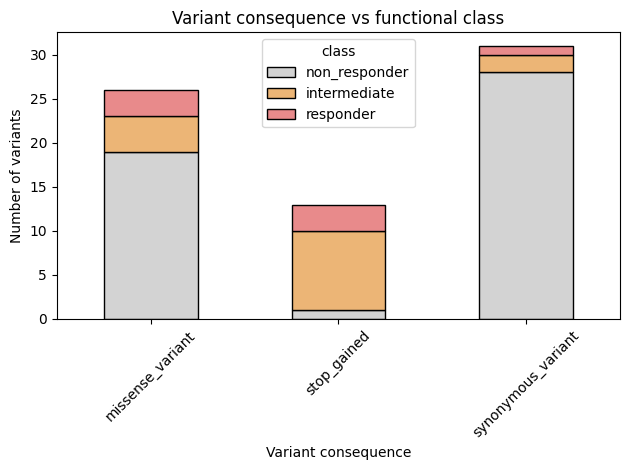

In [ ]:
counts = df2[df2["source"].isin(["ss_lib", "stop_syn_gained_lib", "stop_gained_lib"])].groupby(['consequence', 'class']).size().unstack(fill_value=0)

# sort stacked bars
the_order = ['non_responder', 'intermediate', 'responder']
counts = counts[the_order]

# define colors
categories = list(counts.columns)
color_map = {
    "responder": "#E88A8B",
    "intermediate": "#ECB576",
    "non_responder": "lightgray",
}
colors = [color_map[c] for c in categories]

# the actual plot
counts.plot(
    kind = 'bar',
    stacked = True,
    color = colors,
    edgecolor = "black"
)

plt.xlabel('Variant consequence')
plt.ylabel('Number of variants')
plt.title('Variant consequence vs functional class')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    '/'.join([plotpath, cell_line_oi + "_GMM_vs_consequence.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

plt.show()

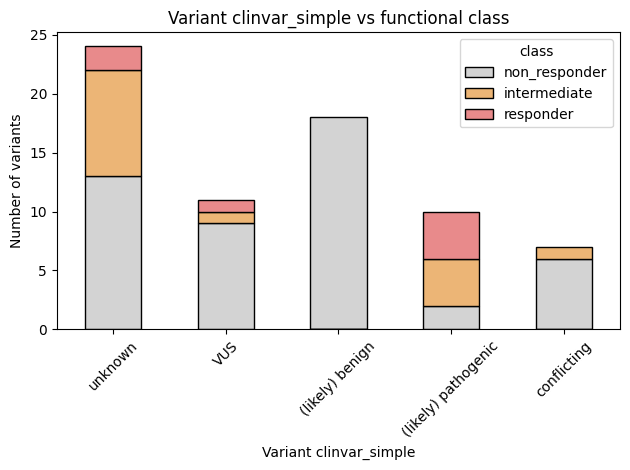

In [ ]:
counts = df2[df2["source"].isin(["ss_lib", "stop_syn_gained_lib", "stop_gained_lib"])].groupby(['clinvar_simple', 'class']).size().unstack(fill_value=0)
counts.index = [x if x not in ["benign", "pathogenic"] else "(likely) " + x for x in counts.index]

# sort x axis and stacked bars
the_order = ['non_responder', 'intermediate', 'responder']
counts = counts[the_order]
the_order = ["unknown", "VUS", "(likely) benign", "(likely) pathogenic", "conflicting"]
counts = counts.reindex(the_order)

# define colors
categories = list(counts.columns)
color_map = {
    "responder": "#E88A8B",
    "benign": "#8FD18F",
    "intermediate": "#ECB576",
    "non_responder": "lightgray",
}
colors = [color_map[c] for c in categories]

# the actual plot
counts.plot(
    kind = 'bar',
    stacked = True,
    color = colors,
    edgecolor = "black"
)

plt.xlabel('Variant clinvar_simple')
plt.ylabel('Number of variants')
plt.title('Variant clinvar_simple vs functional class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    '/'.join([plotpath, cell_line_oi + "_GMM_vs_clinvar.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

plt.show()

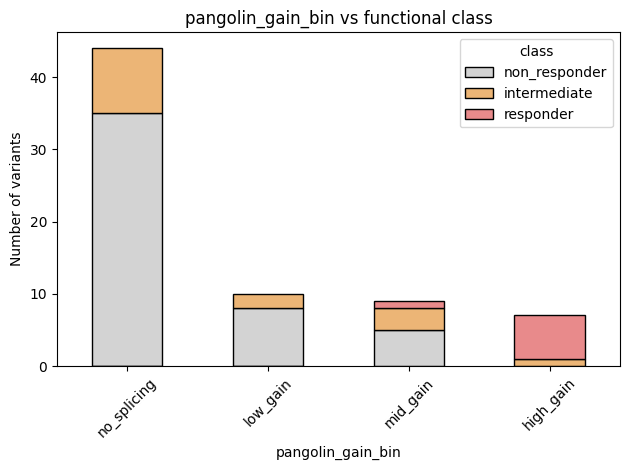

In [ ]:
counts = df2[df2["source"].isin(["ss_lib", "stop_syn_gained_lib", "stop_gained_lib"])].groupby(['pangolin_gain_bin', 'class']).size().unstack(fill_value=0)

# sort x axis and stacked bars
desired_order = ['non_responder', 'intermediate', 'responder']
counts = counts[desired_order]
desired_order = ["no_splicing", "low_gain", "mid_gain", "high_gain"]
counts = counts.reindex(desired_order)

# define colors
categories = list(counts.columns)
color_map = {
    "responder": "#E88A8B",
    "intermediate": "#ECB576",
    "non_responder": "lightgray",
}
colors = [color_map[c] for c in categories]

# the actual plot
counts.plot(
    kind = 'bar',
    stacked = True,
    color = colors,
    edgecolor = "black"
)

plt.xlabel('pangolin_gain_bin')
plt.ylabel('Number of variants')
plt.title('pangolin_gain_bin vs functional class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    '/'.join([plotpath, cell_line_oi + "_GMM_vs_pangolin.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)
plt.show()